# American Option Pricing — PINN vs Binomial Tree (CRR) vs Black-Scholes European

We price an **American put** option under three methods:

| Method | Type | Framework |
|---|---|---|
| **PINN-BS** | American (LCP penalty) | Black-Scholes PDE + early-exercise constraint |
| **Binomial Tree (CRR)** | American (exact DP) | Cox-Ross-Rubinstein lattice, N=1000 steps |
| **BS European** | European lower bound | Closed-form Black-Scholes put |

The American put satisfies the **Linear Complementarity Problem (LCP)**:
$$\min\left(-\mathcal{L}_{BS}V,\; V - (K-S)^+\right) = 0$$

The PINN enforces the early-exercise constraint via a **hinge penalty**:
$$\mathcal{L}_{\text{exercise}} = \left\|\text{ReLU}\left((K-S)^+ - V\right)\right\|^2$$

This term is zero in the continuation region ($V > K-S$) and penalises violations in the exercise region. The **free boundary** — the critical stock price below which early exercise is optimal — is clearly visible in the plots.

**Speed-ups:** `torch.compile`, `torch.autocast`, collocation re-sampled every 50 epochs.


## Library

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import ndtr
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## Black-Scholes — European Put (closed-form lower bound)

In [2]:
class BlackScholes:
    """Vectorised Black-Scholes pricer (numpy)."""
    def __init__(self, r, sigma):
        self.r, self.sigma = r, sigma

    def price(self, S, K, tau, option_type="put"):
        S   = np.maximum(np.asarray(S, dtype=float), 1e-12)
        tau = np.maximum(np.asarray(tau, dtype=float), 1e-10)
        r, sigma = self.r, self.sigma
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
        d2 = d1 - sigma * np.sqrt(tau)
        if option_type == "put":
            return K * np.exp(-r * tau) * ndtr(-d2) - S * ndtr(-d1)
        else:
            return S * ndtr(d1) - K * np.exp(-r * tau) * ndtr(d2)

    def price_grid(self, S_arr, K, tau, option_type="put"):
        return self.price(np.asarray(S_arr, dtype=float), K, tau, option_type)


## Binomial Tree — CRR (American put benchmark)

Cox-Ross-Rubinstein lattice with N steps.
Early exercise enforced at each node: $V_i = \max(V_i^{\text{cont}},\, K - S_i)$.
For N = 1000 this gives accuracy ~0.01% and runs in milliseconds.


In [3]:
class BinomialTree:
    """CRR binomial tree for American options."""
    def __init__(self, r, sigma, N=1000):
        self.r, self.sigma, self.N = r, sigma, N

    def price(self, S0, K, T, option_type="put"):
        N, r, sigma = self.N, self.r, self.sigma
        dt   = T / N
        u    = math.exp(sigma * math.sqrt(dt))
        d    = 1.0 / u
        disc = math.exp(-r * dt)
        p    = (math.exp(r * dt) - d) / (u - d)
        j    = np.arange(N + 1)
        S_T  = S0 * (u ** (N - j)) * (d ** j)
        V    = np.maximum(K - S_T, 0.0) if option_type == "put" else np.maximum(S_T - K, 0.0)
        for i in range(N - 1, -1, -1):
            V   = disc * (p * V[:-1] + (1 - p) * V[1:])
            S_i = S0 * (u ** (i - np.arange(i + 1))) * (d ** np.arange(i + 1))
            V   = np.maximum(V, K - S_i) if option_type == "put" else np.maximum(V, S_i - K)
        return float(V[0])

    def price_grid(self, S_arr, K, T, option_type="put"):
        return np.array([self.price(float(s), K, T, option_type) for s in S_arr])


## PINN Class — American Put (LCP Penalty Method)

The PINN solves the Black-Scholes PDE:
$$\frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S} - rV = 0$$

with boundary conditions:
- **Terminal**: $V(S, T) = (K - S)^+$
- **$S = 0$**: $V(0, t) = K e^{-r(T-t)}$ (put is certain to be exercised)
- **$S = S_{\max}$**: $V(S_{\max}, t) \approx 0$
- **Early exercise**: $V \geq (K - S)^+$ enforced via hinge penalty


In [4]:
class PINN_American_Put(nn.Module):
    def __init__(
        self,
        K, r, sigma, T,
        S_min, S_max, t_min, t_max,
        hidden_layers,
        activation_fun=nn.Tanh,
        loss_weights=None,
        atm_fraction=0.4,
        atm_bandwidth=0.30,
    ):
        super().__init__()
        self.K, self.r, self.sigma, self.T = K, r, sigma, T
        self.S_min, self.S_max = S_min, S_max
        self.t_min, self.t_max = t_min, t_max
        self.atm_fraction = atm_fraction
        self.S_atm_lo = K * (1.0 - atm_bandwidth)
        self.S_atm_hi = K * (1.0 + atm_bandwidth)
        self.mse = nn.MSELoss()

        if loss_weights is None:
            loss_weights = {
                "pde": 1.0, "terminal": 10.0,
                "boundary_S0": 5.0, "boundary_Smax": 1.0,
                "exercise": 8.0,
            }
        self.loss_weights = loss_weights

        layers = [nn.Linear(2, hidden_layers[0]), activation_fun()]
        for i in range(len(hidden_layers) - 1):
            layers += [nn.Linear(hidden_layers[i], hidden_layers[i+1]), activation_fun()]
        layers.append(nn.Linear(hidden_layers[-1], 1))
        self.net = nn.Sequential(*layers)

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, S, t):
        x = torch.cat([S, t], dim=1)
        xs = torch.stack([
            2.0 * (x[:, 0] - self.S_min) / (self.S_max - self.S_min) - 1.0,
            2.0 * (x[:, 1] - self.t_min) / (self.t_max - self.t_min) - 1.0,
        ], dim=1)
        return F.softplus(self.net(xs))

    def _grad(self, y, x):
        return torch.autograd.grad(
            y, x, grad_outputs=torch.ones_like(y),
            create_graph=True, retain_graph=True
        )[0]

    def bs_pde_residual(self, S, t):
        S = S.detach().requires_grad_(True)
        t = t.detach().requires_grad_(True)
        V    = self.forward(S, t)
        V_t  = self._grad(V, t)
        V_S  = self._grad(V, S)
        V_SS = self._grad(V_S, S)
        return V_t + 0.5 * self.sigma**2 * S**2 * V_SS + self.r * S * V_S - self.r * V

    def _sample_S_focused(self, N, dev):
        """
        For American put: concentrate points in ITM (S < K) and ATM zones
        where the early-exercise boundary and highest errors are located.
        30% ATM band, 30% ITM zone [S_min+eps, K], 40% global
        """
        eps   = 1e-6
        N_atm = int(N * 0.30)
        N_itm = int(N * 0.30)
        N_gl  = N - N_atm - N_itm
        S_atm = torch.rand(N_atm, 1, device=dev) * (self.S_atm_hi - self.S_atm_lo) + self.S_atm_lo
        S_itm = torch.rand(N_itm, 1, device=dev) * (self.K - eps) + eps
        S_gl  = torch.rand(N_gl,  1, device=dev) * (self.S_max - eps) + eps
        return torch.cat([S_atm, S_itm, S_gl], dim=0)

    def sample_training_points(self, N_f, N_terminal, N_b):
        dev = next(self.parameters()).device
        S_f  = self._sample_S_focused(N_f, dev)
        t_f  = torch.rand(N_f, 1, device=dev) * (self.t_max - self.t_min) + self.t_min
        S_T  = self._sample_S_focused(N_terminal, dev)
        t_T  = torch.full((N_terminal, 1), self.T, device=dev)
        S_b0 = torch.zeros(N_b, 1, device=dev)
        t_b0 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min
        S_b1 = torch.full((N_b, 1), self.S_max, device=dev)
        t_b1 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min
        S_ex = self._sample_S_focused(N_f, dev)
        t_ex = torch.rand(N_f, 1, device=dev) * (self.t_max - self.t_min) + self.t_min
        return S_f, t_f, S_T, t_T, S_b0, t_b0, S_b1, t_b1, S_ex, t_ex

    def compute_loss_from_data(self, data, pde_weight_override=None):
        S_f, t_f, S_T, t_T, S_b0, t_b0, S_b1, t_b1, S_ex, t_ex = data

        res      = self.bs_pde_residual(S_f, t_f)
        loss_pde = self.mse(res, torch.zeros_like(res))

        # Terminal: V(S,T) = (K-S)+
        V_T      = self.forward(S_T, t_T)
        loss_ter = self.mse(V_T, torch.clamp(self.K - S_T, min=0.0))

        # S=0: put is certain to be exercised -> V = K*exp(-r*(T-t))
        V_b0     = self.forward(S_b0, t_b0)
        tgt_b0   = self.K * torch.exp(-self.r * (self.T - t_b0))
        loss_b0  = self.mse(V_b0, tgt_b0)

        # S=Smax: put is worthless
        V_b1     = self.forward(S_b1, t_b1)
        loss_b1  = self.mse(V_b1, torch.zeros_like(V_b1))

        # Early-exercise penalty: V >= (K-S)+
        V_ex     = self.forward(S_ex, t_ex)
        intrins  = torch.clamp(self.K - S_ex, min=0.0)
        loss_ex  = torch.mean(F.relu(intrins - V_ex) ** 2)

        w_pde = pde_weight_override if pde_weight_override is not None else self.loss_weights["pde"]
        loss  = (w_pde                               * loss_pde
                 + self.loss_weights["terminal"]      * loss_ter
                 + self.loss_weights["boundary_S0"]   * loss_b0
                 + self.loss_weights["boundary_Smax"] * loss_b1
                 + self.loss_weights["exercise"]      * loss_ex)

        return loss, {
            "loss_pde":      loss_pde.item(),
            "loss_terminal": loss_ter.item(),
            "loss_b0":       loss_b0.item(),
            "loss_b1":       loss_b1.item(),
            "loss_exercise": loss_ex.item(),
        }

    def compute_loss(self, N_f, N_terminal, N_b, pde_weight_override=None):
        return self.compute_loss_from_data(
            self.sample_training_points(N_f, N_terminal, N_b),
            pde_weight_override=pde_weight_override
        )


## Initialization

In [5]:
torch.manual_seed(42)
np.random.seed(42)

K     = 100.0
r     = 0.05
sigma = 0.20
T     = 1.0

S_min, S_max = 0.0, 200.0
t_min, t_max = 0.0, T

N_f        = 30_000   # more interior points
N_terminal = 3_000    # more terminal points
N_b        = 1_500    # more boundary points
resample_every = 50

hidden_layers  = [128, 128, 128, 128, 128]  # deeper network (5 layers)
activation_fun = nn.Tanh

loss_weights = {
    "pde":            1.0,
    "terminal":       10.0,
    "boundary_S0":    10.0,  # stronger: S=0 boundary is critical for put
    "boundary_Smax":  1.0,
    "exercise":       15.0,  # stronger: enforce V >= (K-S)+ more aggressively
}

lr     = 1e-3
epochs = 8_000   # more epochs

bs   = BlackScholes(r, sigma)
tree = BinomialTree(r, sigma, N=1000)

model = PINN_American_Put(
    K, r, sigma, T,
    S_min, S_max, t_min, t_max,
    hidden_layers, activation_fun, loss_weights,
    atm_fraction=0.30, atm_bandwidth=0.40,
).to(device)

# torch.compile requires Triton — not available on Windows, disabled
model_eval = model  # same object, weights shared

print(f"Parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Resample every : {resample_every} epochs")


Parameters     : 66,561
Resample every : 50 epochs


## Training + Optimization

**Adaptive PDE weight**: ramps from 1 → 10 over the first 3000 epochs, letting boundary and terminal conditions stabilise before strongly enforcing the PDE interior.

In [6]:
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=800
)

USE_AMP = (device.type == "cuda")
scaler  = torch.cuda.amp.GradScaler(enabled=USE_AMP)

data = model.sample_training_points(N_f, N_terminal, N_b)

pbar = tqdm(range(1, epochs + 1), desc="Training")
for epoch in pbar:
    if epoch % resample_every == 1:
        data = model.sample_training_points(N_f, N_terminal, N_b)

    optimizer.zero_grad(set_to_none=True)
    pde_w = 1.0 + 9.0 * min(epoch / 4_000, 1.0)

    with torch.autocast(device_type=device.type, enabled=USE_AMP):
        loss, parts = model.compute_loss_from_data(data, pde_weight_override=pde_w)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step(loss)

    pbar.set_postfix(loss=f"{loss.item():.3e}", pde_w=f"{pde_w:.1f}")

    if epoch % 500 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | Total {loss.item():.4e} | "
            f"PDE(w={pde_w:.1f}) {parts['loss_pde']:.3e} | "
            f"Terminal {parts['loss_terminal']:.3e} | "
            f"Exercise {parts['loss_exercise']:.3e} | "
            f"S=0 {parts['loss_b0']:.3e} | S=max {parts['loss_b1']:.3e}"
        )

print("\nL-BFGS fine-tuning...")
fixed_data = model.sample_training_points(N_f, N_terminal, N_b)
opt_lbfgs  = torch.optim.LBFGS(
    model.parameters(), lr=1.0,
    max_iter=2_000, max_eval=1_000,
    history_size=100, line_search_fn="strong_wolfe",
)
def closure():
    opt_lbfgs.zero_grad()
    loss, _ = model.compute_loss_from_data(fixed_data, pde_weight_override=10.0)
    loss.backward()
    return loss
opt_lbfgs.step(closure)
print("L-BFGS done.")


C:\Users\Sam\AppData\Local\Temp\ipykernel_23680\743365502.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Training:   0%|          | 0/8000 [00:00<?, ?it/s]

c:\Users\Sam\Desktop\M2QF\Cutting-Edge\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


Epoch     1 | Total 1.3686e+05 | PDE(w=1.0) 2.751e-02 | Terminal 1.709e+03 | Exercise 1.729e+03 | S=0 9.383e+03 | S=max 4.736e-01
Epoch   500 | Total 6.0724e+03 | PDE(w=2.1) 1.174e+01 | Terminal 2.868e+01 | Exercise 2.986e+01 | S=0 5.313e+02 | S=max 0.000e+00
Epoch  1000 | Total 3.6812e+01 | PDE(w=3.2) 4.615e+00 | Terminal 2.720e-01 | Exercise 7.574e-01 | S=0 7.733e-01 | S=max 0.000e+00
Epoch  1500 | Total 7.4636e+01 | PDE(w=4.4) 1.632e+00 | Terminal 2.096e+00 | Exercise 2.715e+00 | S=0 5.798e-01 | S=max 0.000e+00
Epoch  2000 | Total 2.5877e+01 | PDE(w=5.5) 1.562e+00 | Terminal 1.816e-01 | Exercise 9.881e-01 | S=0 6.492e-02 | S=max 3.882e-43
Epoch  2500 | Total 2.7297e+01 | PDE(w=6.6) 6.917e-01 | Terminal 1.590e+00 | Exercise 4.243e-01 | S=0 4.537e-02 | S=max 4.058e-33
Epoch  3000 | Total 2.4848e+01 | PDE(w=7.8) 4.652e-01 | Terminal 7.563e-01 | Exercise 9.107e-01 | S=0 1.912e-03 | S=max 5.860e-25
Epoch  3500 | Total 2.4997e+01 | PDE(w=8.9) 6.828e-01 | Terminal 5.755e-01 | Exercise 8.75

## Evaluation

We compare PINN against the Binomial Tree (American put benchmark) on a full (S, t) grid.
We report both **global** and **ATM-band** (S ∈ [80, 120]) errors.

In [7]:
model_eval.eval()

nS = 60
nT = 30

S_grid_np = np.linspace(S_min + 1.0, S_max, nS)
t_grid_np = np.linspace(t_min + 0.01, t_max - 0.01, nT)

print("Computing Binomial Tree reference grid (may take ~30s)...")
V_tree_np = np.zeros((nS, nT))
for j, t_val in enumerate(t_grid_np):
    tau = T - t_val
    V_tree_np[:, j] = tree.price_grid(S_grid_np, K, tau, option_type="put")

SS_np, TT_np = np.meshgrid(S_grid_np, t_grid_np, indexing="ij")
S_test = torch.tensor(SS_np.reshape(-1, 1), dtype=torch.float32, device=device)
t_test = torch.tensor(TT_np.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    V_pred = model_eval(S_test, t_test).cpu().numpy().reshape(nS, nT)

abs_error = np.abs(V_pred - V_tree_np)
rel_l2    = np.linalg.norm(V_pred - V_tree_np) / (np.linalg.norm(V_tree_np) + 1e-12)
rmse      = np.sqrt(np.mean((V_pred - V_tree_np)**2))
max_err   = np.max(abs_error)

atm_mask    = (S_grid_np >= 80) & (S_grid_np <= 120)
rel_l2_atm  = (np.linalg.norm(V_pred[atm_mask, :] - V_tree_np[atm_mask, :])
               / (np.linalg.norm(V_tree_np[atm_mask, :]) + 1e-12))
max_err_atm = np.max(abs_error[atm_mask, :])

print(f"\nEvaluation vs Binomial Tree (American put benchmark):")
print(f"  Relative L2 error (global)  : {rel_l2:.6e}")
print(f"  Relative L2 error (ATM band): {rel_l2_atm:.6e}")
print(f"  RMSE                        : {rmse:.6e}")
print(f"  Max abs error (global)      : {max_err:.6e}")
print(f"  Max abs error (ATM)         : {max_err_atm:.6e}")


Computing Binomial Tree reference grid (may take ~30s)...

Evaluation vs Binomial Tree (American put benchmark):
  Relative L2 error (global)  : 2.065177e-02
  Relative L2 error (ATM band): 3.939810e-02
  RMSE                        : 8.471491e-01
  Max abs error (global)      : 2.764391e+00
  Max abs error (ATM)         : 1.471236e+00


## Single Cases

For each $t$ slice we print:
- Summary error metrics (global + ATM Rel L2, RMSE, max errors)
- A **pointwise table**: S | PINN | Tree (American) | BS European | EE Premium | Abs error | Rel error %
- A **two-panel plot**: prices (left) and relative error log-scale (right)


In [8]:
def compare_prices_table(model, S_list, t_value=0.5):
    model_eval.eval()
    tau   = T - t_value
    S_arr = np.array(S_list, dtype=float)

    tree_p = tree.price_grid(S_arr, K, tau, option_type="put")
    bs_p   = bs.price_grid(S_arr,   K, tau, option_type="put")

    S_t = torch.tensor(S_arr.reshape(-1, 1), dtype=torch.float32, device=device)
    t_t = torch.full_like(S_t, float(t_value))
    with torch.no_grad():
        pinn_p = model_eval(S_t, t_t).cpu().numpy().flatten()

    abs_err    = np.abs(pinn_p - tree_p)
    rel_err    = abs_err / np.maximum(tree_p, 0.1) * 100
    ee_premium = tree_p - bs_p

    return pd.DataFrame({
        "S":               S_list,
        "t":               t_value,
        "PINN (American)": np.round(pinn_p,     4),
        "Tree (American)": np.round(tree_p,     4),
        "BS (European)":   np.round(bs_p,       4),
        "EE Premium":      np.round(ee_premium, 4),
        "Abs error":       np.round(abs_err,    4),
        "Rel error %":     np.round(rel_err,    3),
    })


S_values = [40, 60, 70, 80, 90, 100, 110, 120, 140, 160]

for t_val in [0.25, 0.5, 0.75]:
    df = compare_prices_table(model, S_values, t_value=t_val)

    atm_rows   = df[df.S.between(80, 120)]
    pinn_arr   = df["PINN (American)"].values
    tree_arr   = df["Tree (American)"].values
    rel_l2_f   = np.linalg.norm(pinn_arr - tree_arr) / (np.linalg.norm(tree_arr) + 1e-12)
    rel_l2_atm = (np.linalg.norm(atm_rows["PINN (American)"].values - atm_rows["Tree (American)"].values)
                  / (np.linalg.norm(atm_rows["Tree (American)"].values) + 1e-12))

    print(f"{'='*65}")
    print(f"  t = {t_val}  (tau = {T - t_val:.2f}),  K={K}, r={r}, sigma={sigma}")
    print(f"{'='*65}")
    print(f"  Rel L2 (full slice)  : {rel_l2_f:.6e}")
    print(f"  Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
    print(f"  Max rel error        : {df['Rel error %'].max():.4f}%")
    print()
    print(df.to_string(index=False))
    print()


  t = 0.25  (tau = 0.75),  K=100.0, r=0.05, sigma=0.2
  Rel L2 (full slice)  : 3.946253e-02
  Rel L2 (ATM [80,120]): 6.078619e-02
  Max rel error        : 6.9900%

  S    t  PINN (American)  Tree (American)  BS (European)  EE Premium  Abs error  Rel error %
 40 0.25        58.488701          60.0000        56.3194      3.6806     1.5113        2.519
 60 0.25        38.379200          40.0000        36.3319      3.6681     1.6208        4.052
 70 0.25        28.158400          30.0000        26.5011      3.4989     1.8416        6.139
 80 0.25        18.602100          20.0000        17.4195      2.5805     1.3979        6.990
 90 0.25        10.777100          11.1110        10.0747      1.0363     0.3339        3.005
100 0.25         5.454500           5.4648         5.0917      0.3731     0.0102        0.187
110 0.25         2.438600           2.3929         2.2665      0.1264     0.0457        1.911
120 0.25         0.976100           0.9426         0.9026      0.0400     0.0335    

## Graphs

### Reference price heatmap (Binomial Tree)

Computing tree heatmap...


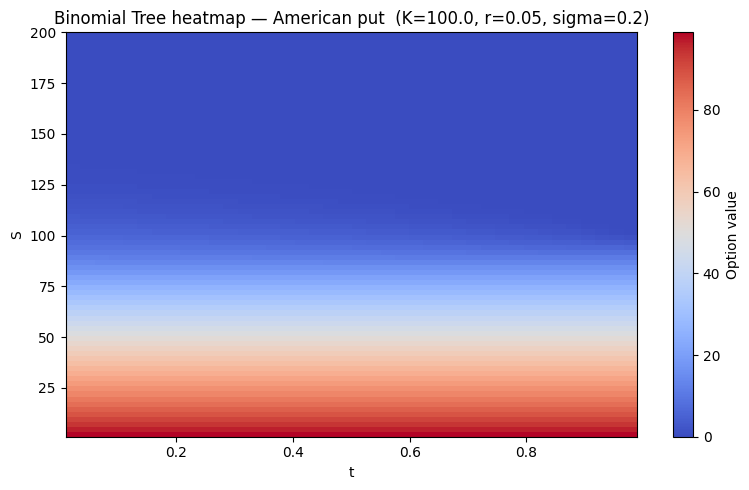

In [9]:
def plot_tree_heatmap(nS=80, nT=40):
    S_vals = np.linspace(S_min + 1.0, S_max, nS)
    t_vals = np.linspace(t_min + 0.01, t_max - 0.01, nT)
    print("Computing tree heatmap...")
    V_tree = np.zeros((nS, nT))
    for j, t_val in enumerate(t_vals):
        V_tree[:, j] = tree.price_grid(S_vals, K, T - t_val, option_type="put")
    plt.figure(figsize=(8, 5))
    im = plt.imshow(V_tree,
                    extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="coolwarm")
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"Binomial Tree heatmap — American put  (K={K}, r={r}, sigma={sigma})")
    plt.colorbar(im, label="Option value")
    plt.tight_layout(); plt.show()

plot_tree_heatmap()


### PINN vs Binomial Tree vs BS European — slice plots with relative error


 t=0.25, tau=0.750
 Rel L2 (full slice)  : 2.536735e-02
 Rel L2 (ATM [80,120]): 4.702872e-02
 RMSE                 : 1.036554e+00
 Max abs error        : 1.838884e+00
 Max rel error        : 7.1943%


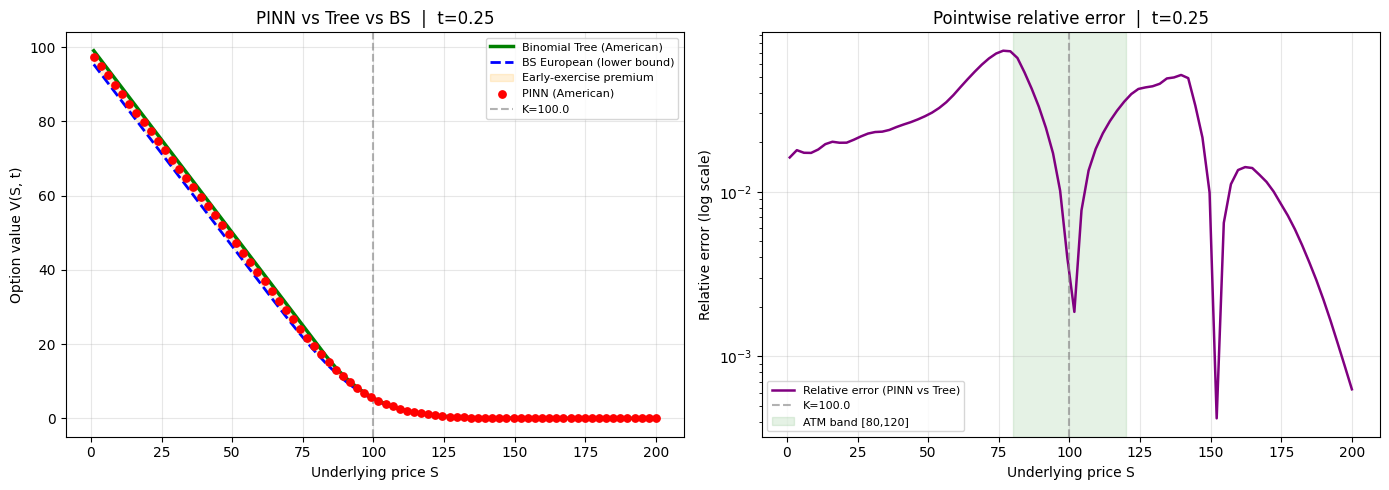


 t=0.5, tau=0.500
 Rel L2 (full slice)  : 1.096276e-02
 Rel L2 (ATM [80,120]): 3.280296e-02
 RMSE                 : 4.478158e-01
 Max abs error        : 1.002481e+00
 Max rel error        : 8.8089%


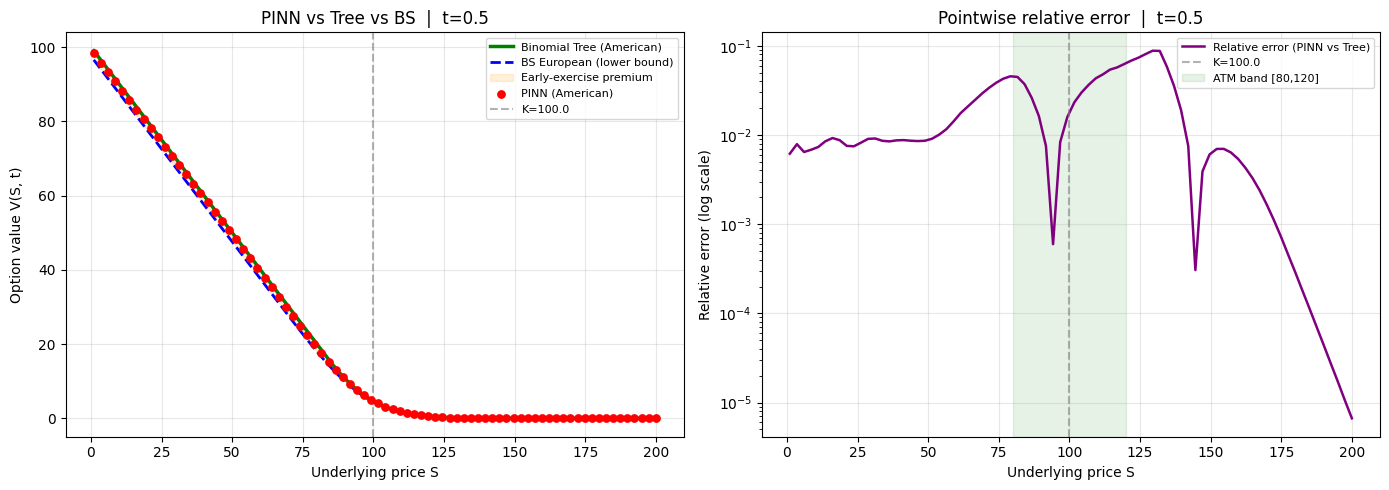


 t=0.75, tau=0.250
 Rel L2 (full slice)  : 5.422266e-03
 Rel L2 (ATM [80,120]): 1.543661e-02
 RMSE                 : 2.214241e-01
 Max abs error        : 5.667357e-01
 Max rel error        : 16.8174%


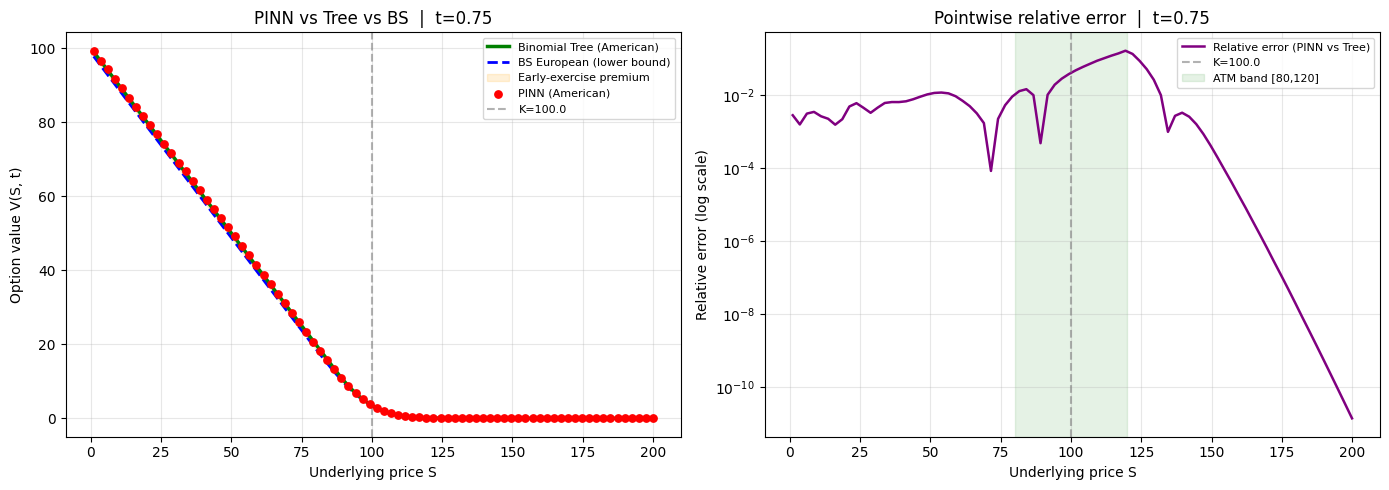

In [10]:
def plot_single_slice(model, t_value=0.5, nS_line=400, nS_scatter=80):
    """
    Two-panel plot:
      Left  — option prices: PINN vs Tree (American) vs BS (European)
      Right — pointwise relative error PINN vs Tree (log scale)
    Also prints full error summary.
    """
    model_eval.eval()
    tau          = T - t_value
    S_line_np    = np.linspace(S_min + 1.0, S_max, nS_line)
    S_scatter_np = np.linspace(S_min + 1.0, S_max, nS_scatter)

    tree_line    = tree.price_grid(S_line_np,    K, tau, option_type="put")
    tree_scatter = tree.price_grid(S_scatter_np, K, tau, option_type="put")
    bs_line      = bs.price_grid(S_line_np,      K, tau, option_type="put")

    S_t = torch.tensor(S_scatter_np.reshape(-1, 1), dtype=torch.float32, device=device)
    t_t = torch.full_like(S_t, float(t_value))
    with torch.no_grad():
        pinn_scatter = model_eval(S_t, t_t).cpu().numpy().flatten()

    abs_err    = np.abs(pinn_scatter - tree_scatter)
    rel_err    = abs_err / np.maximum(tree_scatter, 0.1)
    atm_mask   = (S_scatter_np >= 80) & (S_scatter_np <= 120)
    rel_l2_sl  = np.linalg.norm(pinn_scatter - tree_scatter) / (np.linalg.norm(tree_scatter) + 1e-12)
    rel_l2_atm = (np.linalg.norm(pinn_scatter[atm_mask] - tree_scatter[atm_mask])
                  / (np.linalg.norm(tree_scatter[atm_mask]) + 1e-12))

    print(f"\n{'='*55}")
    print(f" t={t_value}, tau={tau:.3f}")
    print(f"{'='*55}")
    print(f" Rel L2 (full slice)  : {rel_l2_sl:.6e}")
    print(f" Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
    print(f" RMSE                 : {np.sqrt(np.mean((pinn_scatter - tree_scatter)**2)):.6e}")
    print(f" Max abs error        : {np.max(abs_err):.6e}")
    print(f" Max rel error        : {np.max(rel_err):.4%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(S_line_np, tree_line, color="green", lw=2.5, label="Binomial Tree (American)", zorder=3)
    ax.plot(S_line_np, bs_line,   color="blue",  lw=2.0, ls="--", label="BS European (lower bound)", zorder=2)
    ax.fill_between(S_line_np, bs_line, tree_line, alpha=0.15, color="orange", label="Early-exercise premium")
    ax.scatter(S_scatter_np, pinn_scatter, color="red", s=28, label="PINN (American)", zorder=4)
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.set_xlabel("Underlying price S")
    ax.set_ylabel("Option value V(S, t)")
    ax.set_title(f"PINN vs Tree vs BS  |  t={t_value}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.semilogy(S_scatter_np, rel_err, color="purple", lw=1.8, label="Relative error (PINN vs Tree)")
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.axvspan(80, 120, alpha=0.10, color="green", label="ATM band [80,120]")
    ax.set_xlabel("Underlying price S")
    ax.set_ylabel("Relative error (log scale)")
    ax.set_title(f"Pointwise relative error  |  t={t_value}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


for t_val in [0.25, 0.5, 0.75]:
    plot_single_slice(model, t_value=t_val)


### Error Heatmap — |PINN - Binomial Tree|

Computing tree reference for error heatmap...


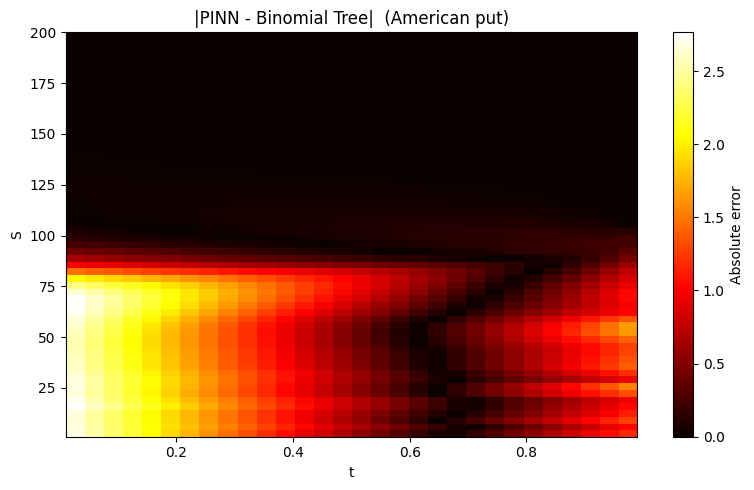

In [11]:
def plot_error_heatmap(model, nS=60, nT=30):
    model_eval.eval()
    S_vals = np.linspace(S_min + 1.0, S_max, nS)
    t_vals = np.linspace(t_min + 0.01, t_max - 0.01, nT)
    print("Computing tree reference for error heatmap...")
    V_tree = np.zeros((nS, nT))
    for j, t_val in enumerate(t_vals):
        V_tree[:, j] = tree.price_grid(S_vals, K, T - t_val, option_type="put")
    SS, TT = np.meshgrid(S_vals, t_vals, indexing="ij")
    S_t = torch.tensor(SS.reshape(-1, 1), dtype=torch.float32, device=device)
    t_t = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device)
    with torch.no_grad():
        V_pinn = model_eval(S_t, t_t).cpu().numpy().reshape(nS, nT)
    err = np.abs(V_pinn - V_tree)
    plt.figure(figsize=(8, 5))
    im = plt.imshow(err,
                    extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="hot")
    plt.xlabel("t"); plt.ylabel("S")
    plt.title("|PINN - Binomial Tree|  (American put)")
    plt.colorbar(im, label="Absolute error")
    plt.tight_layout(); plt.show()

plot_error_heatmap(model)


### Bonus: PINN vs Tree vs BS across time slices

Because the PINN learned the **full 2D surface**, we can query it at any $(S, t)$.
Each panel shows one time slice with all three methods and the early-exercise premium (shaded).
The left boundary of the orange region marks the **free boundary** — the critical $S^*$ below which early exercise is optimal.


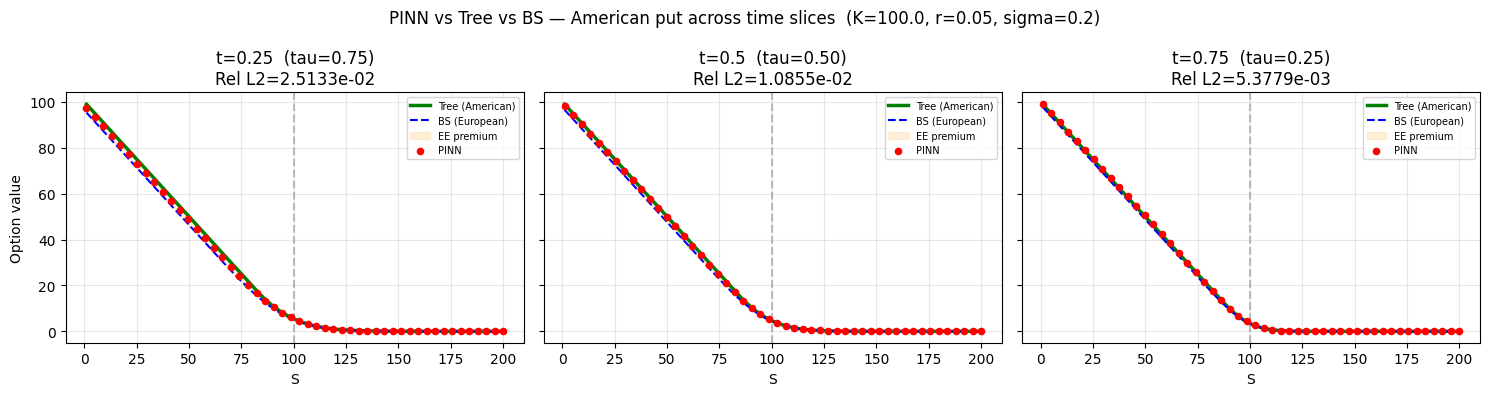

In [12]:
def plot_pinn_vs_tree_multiple_t(model, t_values=None, nS_line=300, nS_scatter=50):
    """
    Same structure as 'multiple variance levels' in the Heston notebook.
    Each panel: one time slice showing PINN, Tree (American), BS (European).
    """
    if t_values is None:
        t_values = [0.25, 0.5, 0.75]
    model_eval.eval()
    S_line   = np.linspace(S_min + 1.0, S_max, nS_line)
    S_scatter = np.linspace(S_min + 1.0, S_max, nS_scatter)

    fig, axes = plt.subplots(1, len(t_values), figsize=(5 * len(t_values), 4), sharey=True)
    if len(t_values) == 1:
        axes = [axes]

    for ax, t_val in zip(axes, t_values):
        tau = T - t_val

        tree_line    = tree.price_grid(S_line,    K, tau, option_type="put")
        tree_scatter = tree.price_grid(S_scatter, K, tau, option_type="put")
        bs_line      = bs.price_grid(S_line,      K, tau, option_type="put")

        S_t = torch.tensor(S_scatter.reshape(-1, 1), dtype=torch.float32, device=device)
        t_t = torch.full_like(S_t, float(t_val))
        with torch.no_grad():
            pinn_scatter = model_eval(S_t, t_t).cpu().numpy().flatten()

        rel_l2 = (np.linalg.norm(pinn_scatter - tree_scatter)
                  / (np.linalg.norm(tree_scatter) + 1e-12))

        ax.plot(S_line, tree_line, color="green", lw=2.5, label="Tree (American)")
        ax.plot(S_line, bs_line,   color="blue",  lw=1.5, ls="--", label="BS (European)")
        ax.fill_between(S_line, bs_line, tree_line, alpha=0.15, color="orange", label="EE premium")
        ax.scatter(S_scatter, pinn_scatter, color="red", s=20, label="PINN", zorder=4)
        ax.axvline(K, color="gray", ls="--", alpha=0.5)
        ax.set_title(f"t={t_val}  (tau={tau:.2f})\nRel L2={rel_l2:.4e}")
        ax.set_xlabel("S")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    axes[0].set_ylabel("Option value")
    fig.suptitle(
        f"PINN vs Tree vs BS — American put across time slices  (K={K}, r={r}, sigma={sigma})",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


plot_pinn_vs_tree_multiple_t(model, t_values=[0.25, 0.5, 0.75])
